<a href="https://colab.research.google.com/github/Mariama-Bawa/Monthly_Armed_Robberies_in_Boston/blob/main/Monthly_Armed_Robberies_in_Boston.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## **1. Chargement et Préparation des Données**

In [ ]:
df=pd.read_csv('monthly-robberies.csv',header=0, index_col=0,parse_dates=True)
df.head()

,Robberies
Month,
1966-01-01,41
1966-02-01,39
1966-03-01,50
1966-04-01,40
1966-05-01,43


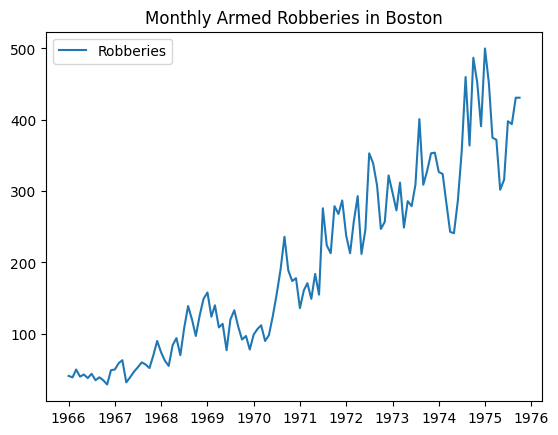

In [ ]:
plt.plot(df, label="Robberies")
plt.title("Monthly Armed Robberies in Boston")
plt.legend()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 118 entries, 1966-01-01 to 1975-10-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Robberies  118 non-null    int64
dtypes: int64(1)
memory usage: 1.8 KB


In [ ]:
df.isnull().sum()

,0
Robberies,0


## **2. Analyse Exploratoire**

### 2.1 Statistiques Descriptives

In [ ]:
print(df.describe())
print("la variance:",df.var())

        Robberies
count  118.000000
mean   196.288136
std    128.043602
min     29.000000
25%     85.500000
50%    166.000000
75%    296.750000
max    500.000000
la variance: Robberies    16395.164132
dtype: float64


### 2.2 Visualisation Générale de la Série

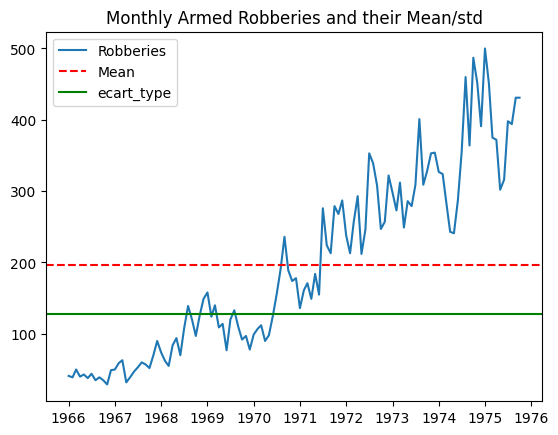

In [ ]:
plt.plot(df['Robberies'], label="Robberies")
plt.axhline(df['Robberies'].mean(), color='red', linestyle='--', label='Mean')
plt.axhline(df['Robberies'].std(), color='green', linestyle='-', label='ecart_type')
plt.title("Monthly Armed Robberies and their Mean/std")
plt.legend()
plt.show()

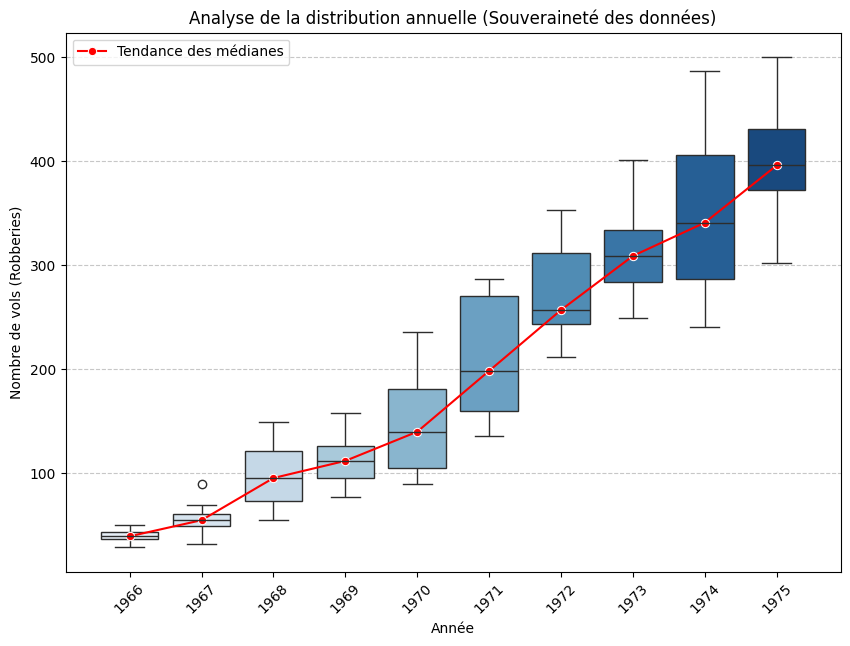

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
data_plot = df.copy()
data_plot['Year'] = data_plot.index.year
plt.figure(figsize=(10, 7))
# Création des boîtes à moustaches par année
sns.boxplot(x='Year', y='Robberies', data=data_plot, palette="Blues")
# Superposition d'une ligne reliant les médianes pour voir la tendance
sns.lineplot(x=range(len(data_plot['Year'].unique())),
y=data_plot.groupby('Year')['Robberies'].median(),
color='red', marker='o', label='Tendance des médianes')
plt.title("Analyse de la distribution annuelle (Souveraineté des données)")
plt.xlabel("Année")
plt.ylabel("Nombre de vols (Robberies)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## **3. Décomposition de la Série Temporelle**

### 3.1 Modèle Additif

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

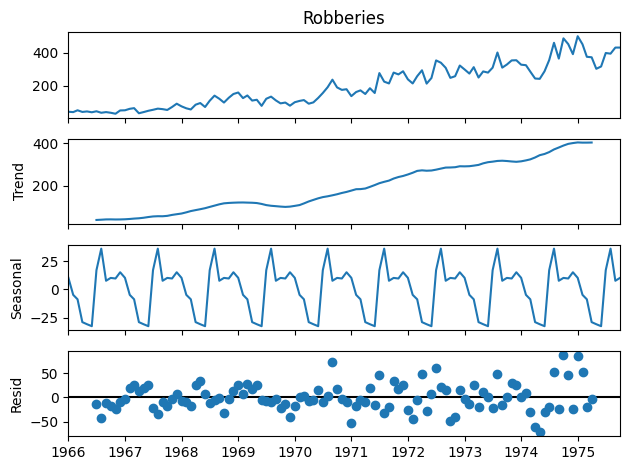

In [ ]:
decomp_add = seasonal_decompose(df['Robberies'], model='additive', period=12)
decomp_add.plot()
plt.show()

### 3.2 Modèle Multiplicatif

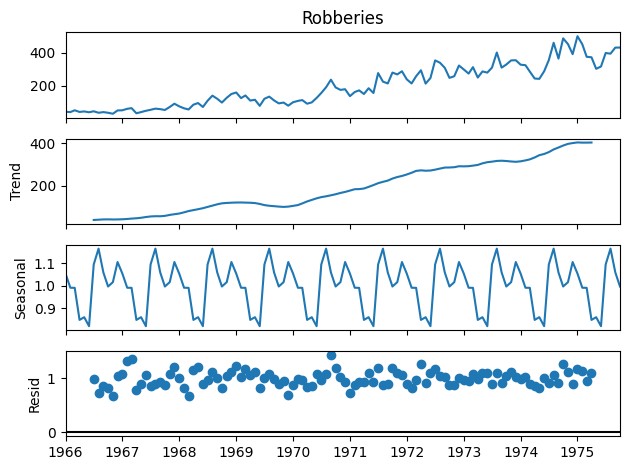

In [ ]:
decomp_mltp = seasonal_decompose(df['Robberies'], model='multiplicative', period=12)
decomp_mltp.plot()
plt.show()

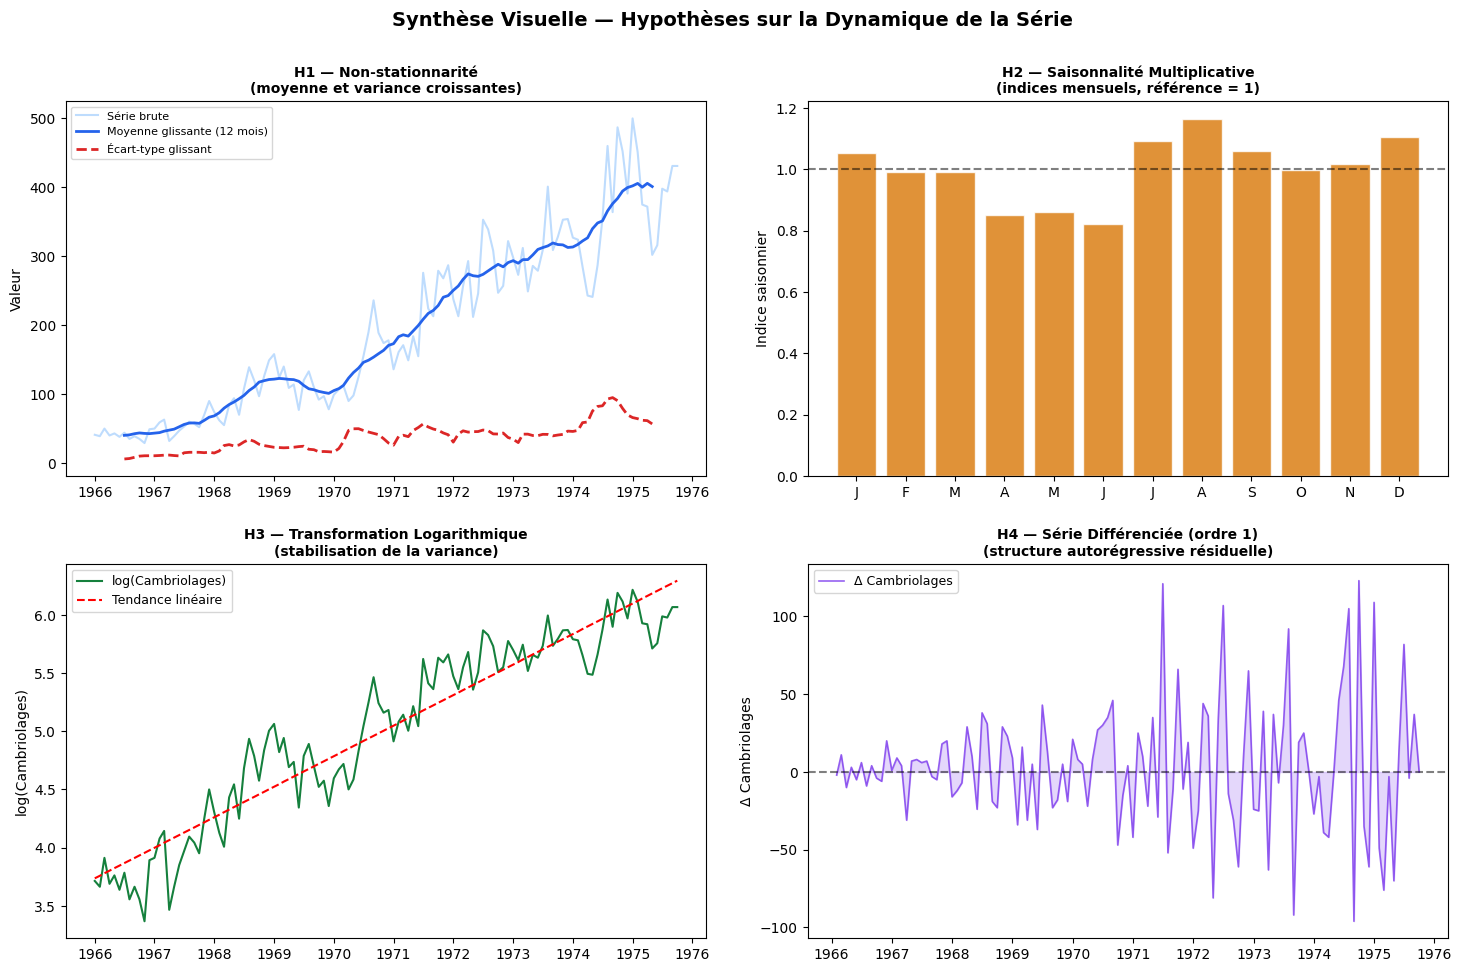

Figure 6 : Synthèse des quatre hypothèses sur la dynamique.


In [ ]:
# === Synthèse visuelle des hypothèses ===
series=df['Robberies']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Synthèse Visuelle — Hypothèses sur la Dynamique de la Série',
             fontsize=14, fontweight='bold')

# H1 — Évolution de la moyenne glissante (non-stationnarité)
ax = axes[0, 0]
roll_mean = series.rolling(window=12, center=True).mean()
roll_std  = series.rolling(window=12, center=True).std()
ax.plot(series, color='#93C5FD', alpha=0.6, label='Série brute')
ax.plot(roll_mean, color='#2563EB', linewidth=2, label='Moyenne glissante (12 mois)')
ax.plot(roll_std,  color='#DC2626', linewidth=2, linestyle='--', label='Écart-type glissant')
ax.set_title('H1 — Non-stationnarité\n(moyenne et variance croissantes)', fontsize=10, fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylabel('Valeur')

# H2 — Saisonnalité : indices mensuels multiplicatifs
ax = axes[0, 1]
seasonal_one_year = decomp_mltp.seasonal[:12]
ax.bar(range(1, 13), seasonal_one_year.values, color='#D97706', alpha=0.8, edgecolor='white')
ax.axhline(1, color='black', linestyle='--', alpha=0.5)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_title('H2 — Saisonnalité Multiplicative\n(indices mensuels, référence = 1)', fontsize=10, fontweight='bold')
ax.set_ylabel('Indice saisonnier')

# H3 — Série log-transformée (tendance stochastique)
ax = axes[1, 0]
log_series = np.log(series)
ax.plot(log_series, color='#15803D', linewidth=1.5, label='log(Cambriolages)')
# Régression linéaire sur log
x = np.arange(len(log_series))
slope, intercept = np.polyfit(x, log_series.values, 1)
ax.plot(log_series.index, intercept + slope * x, 'r--', linewidth=1.5, label='Tendance linéaire')
ax.set_title('H3 — Transformation Logarithmique\n(stabilisation de la variance)', fontsize=10, fontweight='bold')
ax.set_ylabel('log(Cambriolages)')
ax.legend(fontsize=9)

# H4 — Série différenciée (mise en évidence de l'autocorrélation)
ax = axes[1, 1]
diff_series = series.diff().dropna()
ax.plot(diff_series, color='#7C3AED', linewidth=1.2, alpha=0.8, label='Δ Cambriolages')
ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.fill_between(diff_series.index, 0, diff_series, alpha=0.2, color='#7C3AED')
ax.set_title('H4 — Série Différenciée (ordre 1)\n(structure autorégressive résiduelle)', fontsize=10, fontweight='bold')
ax.set_ylabel('Δ Cambriolages')
ax.legend(fontsize=9)

plt.tight_layout(pad=2)
plt.savefig('fig6_synthese_hypotheses.png', bbox_inches='tight')
plt.show()
print("Figure 6 : Synthèse des quatre hypothèses sur la dynamique.")

##**2. Transformation et préparation**

###2.1.Feature engineering

In [ ]:
from pandas import DataFrame
dataframe = DataFrame()
dataframe['month'] = [df.index[i].month for i in range(len(df))]
dataframe['day'] = [df.index[i].day for i in range(len(df))]
dataframe['Robberies'] = df['Robberies'].values
print(dataframe.head())

   month  day  Robberies
0      1    1         41
1      2    1         39
2      3    1         50
3      4    1         40
4      5    1         43


In [ ]:
from pandas import concat
temps = DataFrame(df.values)
dataframe = concat([temps.shift(1), temps], axis=1)
dataframe.columns = ['t', 't+1']
print(dataframe.head(5))

      t  t+1
0   NaN   41
1  41.0   39
2  39.0   50
3  50.0   40
4  40.0   43


In [ ]:
shifted = temps.shift(1)
window = shifted.rolling(window=2)
means = window.mean()
dataframe = concat([means, temps], axis=1)
dataframe.columns = ['mean(t-1,t)', 't+1']
print(dataframe.head(5))

   mean(t-1,t)  t+1
0          NaN   41
1          NaN   39
2         40.0   50
3         44.5   40
4         45.0   43


In [ ]:
width = 3
shifted = temps.shift(width - 1)
window = shifted.rolling(window=width)
dataframe = concat([window.min(), window.mean(), window.max(), temps], axis=1)
dataframe.columns = ['min', 'mean', 'max', 't+1']
print(dataframe.head(5))

    min       mean   max  t+1
0   NaN        NaN   NaN   41
1   NaN        NaN   NaN   39
2   NaN        NaN   NaN   50
3   NaN        NaN   NaN   40
4  39.0  43.333333  50.0   43


###2.2. Tests de stationnarité (ADF, KPSS)

In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df)
print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("\nCritical Values:")
for key, value in result[4].items():
   print(f"{key}: {value:.3f}")

ADF Statistic: 1.001102140245781
p-value: 0.994277563805723

Critical Values:
1%: -3.494
5%: -2.889
10%: -2.582


In [ ]:
from statsmodels.tsa.stattools import kpss

# Test KPSS
result = kpss(df, regression='ct')#reg=c=>stationnarité autour d’une constante.
#reg=ct=>stationnarité autour d’une tendance.
print("KPSS Statistic:", result[0])
print("p-value:", result[1])
print("\nCritical Values:")
for key, value in result[3].items():
    print(f"{key}: {value:.3f}")

KPSS Statistic: 0.17371592077274467
p-value: 0.026903399356046104

Critical Values:
10%: 0.119
5%: 0.146
2.5%: 0.176
1%: 0.216


###2.3. Transformations (log, racine carrée...) et Différenciation

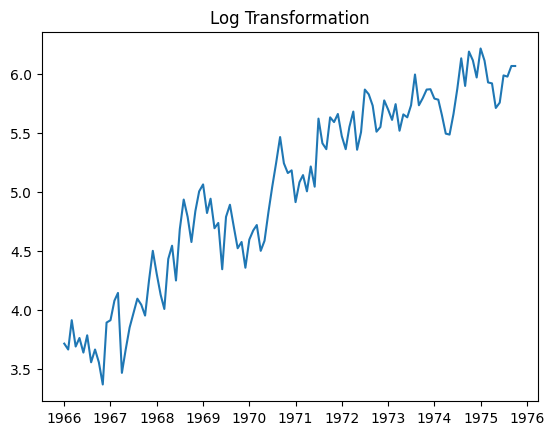

In [ ]:
data_log = np.log(df)
plt.plot(data_log)
plt.title("Log Transformation")
plt.show()

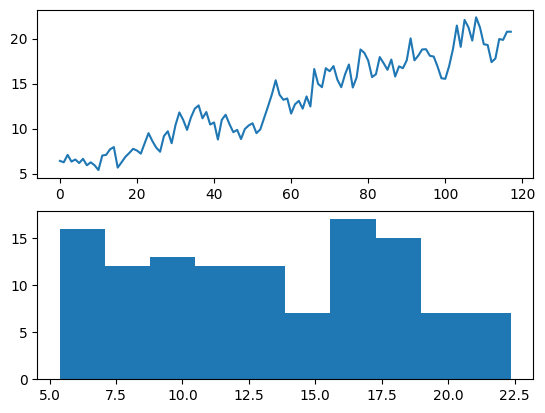

In [ ]:
from pandas import  DataFrame
from math import sqrt
import numpy as np
dataframe = DataFrame(df.values)
dataframe.columns = ['Robberies']
dataframe['Robberies'] = np.sqrt(dataframe['Robberies'])

plt.figure(1)
# line plot
plt.subplot(211)
plt.plot(dataframe['Robberies'])
# histogram
plt.subplot(212)
plt.hist(dataframe['Robberies'])
plt.show()

Lambda: 0.31677983051198816


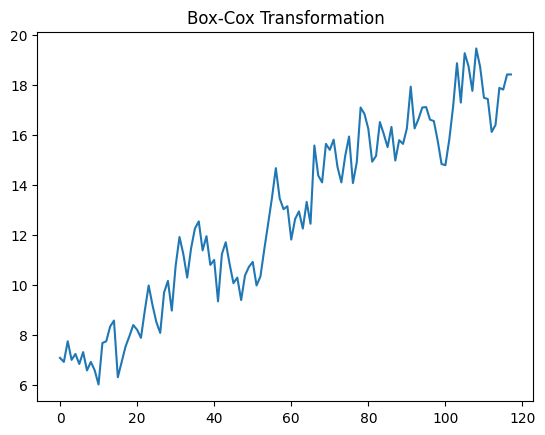

In [ ]:
from scipy.stats import boxcox

data_boxcox, lam = boxcox(df.values.flatten())
print("Lambda:", lam)
plt.plot(data_boxcox)
plt.title("Box-Cox Transformation")
plt.show()

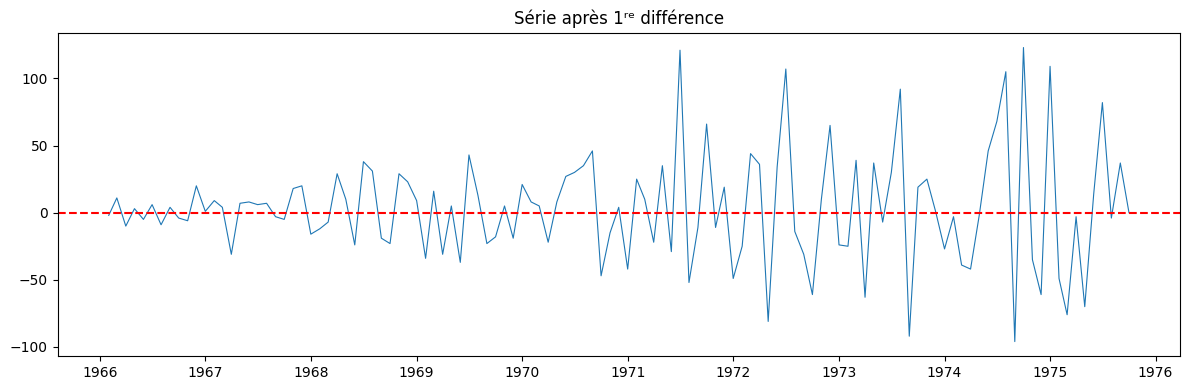

(np.float64(-7.42856447506721), np.float64(6.450795412686658e-11), 10, 106, {'1%': np.float64(-3.4936021509366793), '5%': np.float64(-2.8892174239808703), '10%': np.float64(-2.58153320754717)}, np.float64(1041.4791856387887))


In [ ]:
#1ʳᵉ différence : Yₜ = Xₜ - Xₜ₋₁
diff1 = series.diff()
plt.figure(figsize=(12,4))
plt.plot(diff1, linewidth=0.8)
plt.axhline(0, color='red', linestyle='--')
plt.title('Série après 1ʳᵉ différence')
plt.tight_layout()
plt.show()
print(adfuller(diff1.dropna()))  # p < 0.05 → stationnaire après différenciation

###2.4. Analyse ACF/PACF

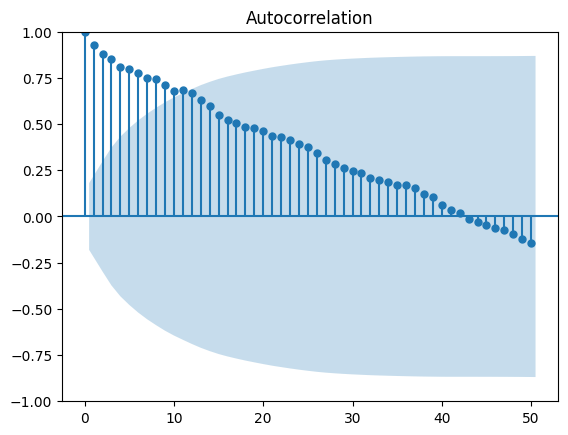

In [ ]:
from pandas.plotting import autocorrelation_plot
plot_acf(series, lags=50)
plt.show()

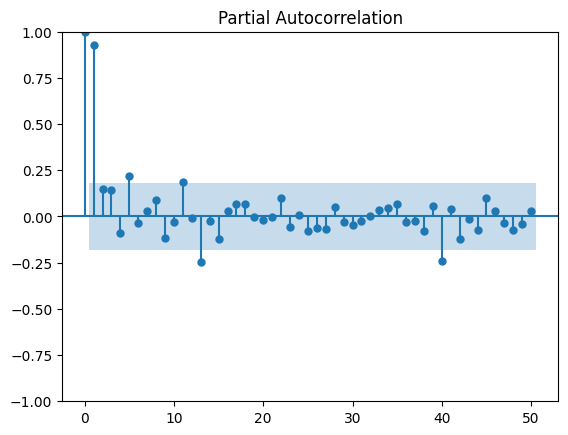

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(series.diff(), lags=50)
plt.show()

###2.5. Découpage train/test

In [ ]:
train_size = int(len(df) * 0.8)
train = df[:train_size]
test = df[train_size:]
print("Train size:", len(train))
print("Test size:", len(test))

Train size: 94
Test size: 24


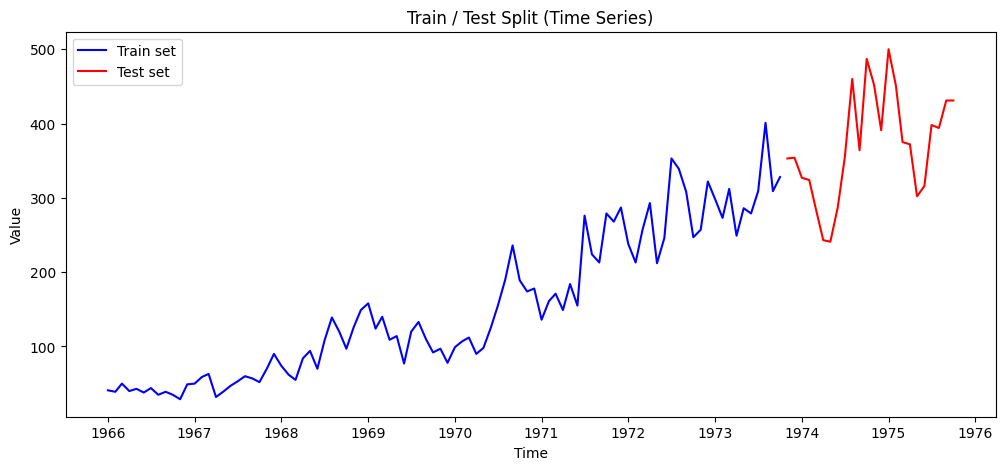

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
# Train
plt.plot(train, label="Train set", color="blue")
# Test (avec son vrai index)
plt.plot(test, label="Test set", color="red")
plt.title("Train / Test Split (Time Series)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()

##**3. Modélisation**

###3.1. Modèles de référence (naïf, moyenne mobile)

predicted=43.333333, expected=40.000000
predicted=43.000000, expected=43.000000
predicted=44.333333, expected=38.000000
predicted=40.333333, expected=44.000000
predicted=41.666667, expected=35.000000
predicted=39.000000, expected=39.000000
predicted=39.333333, expected=35.000000
predicted=36.333333, expected=29.000000
predicted=34.333333, expected=49.000000
predicted=37.666667, expected=50.000000
predicted=42.666667, expected=59.000000
predicted=52.666667, expected=63.000000
predicted=57.333333, expected=32.000000
predicted=51.333333, expected=39.000000
predicted=44.666667, expected=47.000000
predicted=39.333333, expected=53.000000
predicted=46.333333, expected=60.000000
predicted=53.333333, expected=57.000000
predicted=56.666667, expected=52.000000
predicted=56.333333, expected=70.000000
predicted=59.666667, expected=90.000000
predicted=70.666667, expected=74.000000
predicted=78.000000, expected=62.000000
predicted=75.333333, expected=55.000000
predicted=63.666667, expected=84.000000


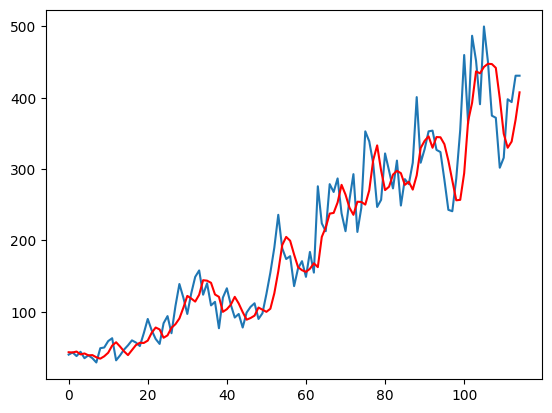

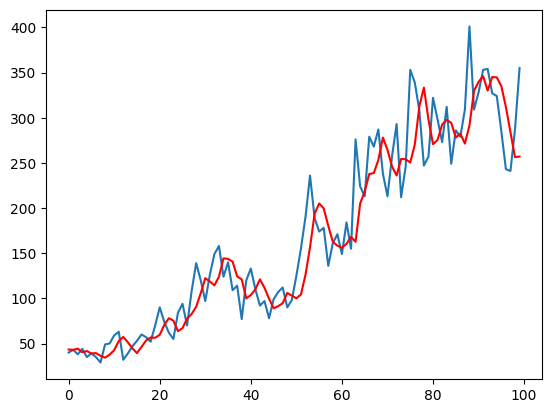

In [ ]:
from sklearn.metrics import mean_squared_error
from math import sqrt
X = df.values
window = 3
history = [X[i] for i in range(window)]
test = [X[i] for i in range(window, len(X))]
predictions = list()
# walk forward over time steps in test
for t in range(len(test)):
   length = len(history)
   yhat = np.mean([history[i] for i in range(length-window,length)])
   obs = test[t]
   predictions.append(yhat)
   history.append(obs)
   print('predicted=%f, expected=%f' % (yhat, obs))
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)

# plot
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()
# zoom plot
plt.plot(test[:100])
plt.plot(predictions[:100], color='red')
plt.show()

In [ ]:
pred_baseline = []
history = list(train.values)
for t in range(len(test)):
   yhat = history[-1] # y(t) = y(t-1)
   pred_baseline.append(yhat)
   history.append(test[t]) # update avec vraie valeur
predictions = np.array(pred_baseline)
print("Baseline Predictions:", predictions)

Baseline Predictions: [[328]
 [ 40]
 [ 43]
 [ 38]
 [ 44]
 [ 35]
 [ 39]
 [ 35]
 [ 29]
 [ 49]
 [ 50]
 [ 59]
 [ 63]
 [ 32]
 [ 39]
 [ 47]
 [ 53]
 [ 60]
 [ 57]
 [ 52]
 [ 70]
 [ 90]
 [ 74]
 [ 62]
 [ 55]
 [ 84]
 [ 94]
 [ 70]
 [108]
 [139]
 [120]
 [ 97]
 [126]
 [149]
 [158]
 [124]
 [140]
 [109]
 [114]
 [ 77]
 [120]
 [133]
 [110]
 [ 92]
 [ 97]
 [ 78]
 [ 99]
 [107]
 [112]
 [ 90]
 [ 98]
 [125]
 [155]
 [190]
 [236]
 [189]
 [174]
 [178]
 [136]
 [161]
 [171]
 [149]
 [184]
 [155]
 [276]
 [224]
 [213]
 [279]
 [268]
 [287]
 [238]
 [213]
 [257]
 [293]
 [212]
 [246]
 [353]
 [339]
 [308]
 [247]
 [257]
 [322]
 [298]
 [273]
 [312]
 [249]
 [286]
 [279]
 [309]
 [401]
 [309]
 [328]
 [353]
 [354]
 [327]
 [324]
 [285]
 [243]
 [241]
 [287]
 [355]
 [460]
 [364]
 [487]
 [452]
 [391]
 [500]
 [451]
 [375]
 [372]
 [302]
 [316]
 [398]
 [394]
 [431]]


### 3.2. Bonnes pratiques d'évaluation

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
from math import sqrt
#avec library
mae = mean_absolute_error(test, predictions)
print('MAE: %f' % mae)
mse = mean_squared_error(test, predictions)
print("MSE :", mse)
rmse= sqrt(mse)
print("RMSE :", rmse)


MAE: 32.965217
MSE : 2444.008695652174
RMSE : 49.436916324262924


In [ ]:
#avec juste numpy
mae=(1/len(test))*np.sum(np.abs(test-predictions))
print('MAE: %f' % mae)
mse=(1/len(test))*np.sum((test-predictions)**2)
print("MSE :", mse)
rmse= np.sqrt(mse)
print("RMSE :", rmse)

MAE: 32.965217
MSE : 2444.008695652174
RMSE : 49.436916324262924


### 3.3. Walk-forward validation :

In [ ]:
def model_persistence(x):
  return x

In [ ]:
values = DataFrame(df.values)
dataframe = concat([values.shift(1), values],
axis=1)
dataframe.columns = ['t', 't+1']
print(dataframe.head(5))

      t  t+1
0   NaN   41
1  41.0   39
2  39.0   50
3  50.0   40
4  40.0   43


In [ ]:
X = dataframe.values
train_size = int(len(X) * 0.66)
train, test = X[1:train_size], X[train_size:]
train_X, train_y = train[:,0], train[:,1]
test_X, test_y = test[:,0], test[:,1]

In [ ]:
predictions = list()
for x in test_X:
  yhat = model_persistence(x)
  predictions.append(yhat)
rmse = sqrt(mean_squared_error(test_y, predictions))
print('Test RMSE: %.3f' % rmse)

Test RMSE: 56.974


### 3.4. Auto-Regression(AR) :

Ayant déjà trouver avec la partie 2.4 que p=1, nous allons l'utiliser pour auto-regression

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Modèle AR(1)
model_ar = ARIMA(train_y, order=(1, 0, 0))
model_ar_fit = model_ar.fit()
print(model_ar_fit.summary())

# prédictions
predictions_ar = model_ar_fit.forecast(steps=len(test_y))
# Calcul du RMSE
rmse_ar = sqrt(mean_squared_error(test_y, predictions_ar))
print('RMSE AR(1): %.3f' % rmse_ar)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   76
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -364.512
Date:                Sun, 10 May 2026   AIC                            735.023
Time:                        16:54:13   BIC                            742.015
Sample:                             0   HQIC                           737.818
                                 - 76                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        121.1920     43.370      2.794      0.005      36.189     206.195
ar.L1          0.9193      0.046     19.945      0.000       0.829       1.010
sigma2       837.1431     92.768      9.024      0.0

### 3.5. Modèle à Moyenne Mobile : MA(2)

In [ ]:
# Modèle MA(2)
model_ma = ARIMA(train_y, order=(0, 0, 2))
model_ma_fit = model_ma.fit()
print(model_ma_fit.summary())

# Prédictions
predictions_ma = model_ma_fit.forecast(steps=len(test_y))
# Calcul du RMSE
rmse_ma = sqrt(mean_squared_error(test_y, predictions_ma))
print('RMSE MA(2)): %.3f' % rmse_ma)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   76
Model:                 ARIMA(0, 0, 2)   Log Likelihood                -387.309
Date:                Sun, 10 May 2026   AIC                            782.619
Time:                        16:54:13   BIC                            791.941
Sample:                             0   HQIC                           786.344
                                 - 76                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        118.8713     14.091      8.436      0.000      91.254     146.489
ma.L1          0.8106      0.101      8.033      0.000       0.613       1.008
ma.L2          0.6696      0.081      8.284      0.0

### 3.6. Modèle ARMA : ARMA(2,2)

Maintenant en utilisant les valeurs de p et de q obtenu, nous allons applique chercher un modèle ARIMA

In [ ]:
model_arma = ARIMA(train_y, order=(2, 0, 2))
model_arma_fit = model_arma.fit()
print(model_arma_fit.summary())

# Prédictions
predictions_arma = model_arma_fit.forecast(steps=len(test_y))

# Calcul du RMSE
rmse_arma = sqrt(mean_squared_error(test_y, predictions_arma))
print('RMSE ARMA(2, 2): %.3f' % rmse_arma)


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   76
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -360.822
Date:                Sun, 10 May 2026   AIC                            733.644
Time:                        16:54:13   BIC                            747.629
Sample:                             0   HQIC                           739.233
                                 - 76                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        130.1221     64.391      2.021      0.043       3.919     256.326
ar.L1          0.3996      0.677      0.591      0.555      -0.927       1.726
ar.L2          0.5681      0.653      0.870      0.3

### 3.7. Modèle ARIMA : ARiMA(2,1,0)

Nous avions vu que la série n'était pas setationnaire on va donc applique un différiencing sachant que d=1, on va determiner le p et q correspondant

In [ ]:
import itertools
import warnings
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

# Définir l'espace de recherche (p, d=1, q)
p_range = range(1, 4)
q_range = range(0, 6) #
best_aic = float("inf")
best_order = None

# Grid Search
for p, q in itertools.product(p_range, q_range):
    try:
        # On fixe d=1 comme déterminé précédemment
        model = ARIMA(train_y, order=(p, 1, q))
        results = model.fit()

        # Le critère AIC
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = (p, 1, q)
    except:
        continue

print(f'Meilleure configuration : ARIMA{best_order} avec AIC = {best_aic:.2f}')

Meilleure configuration : ARIMA(2, 1, 0) avec AIC = 716.98


In [ ]:
#Maintenant en utilisant le rmse
import itertools
import warnings
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

warnings.filterwarnings("ignore")

# Définition des l'espace de recherche
p_range = range(1, 4)
q_range = range(0, 6)
best_rmse = float("inf")
best_order = None

print("Recherche de la meilleure configuration (RMSE)...")

# Grid Search
for p, q in itertools.product(p_range, q_range):
    try:
        # 1. Entraînement sur l'ensemble train_y
        model = ARIMA(train_y, order=(p, 1, q))
        model_fit = model.fit()

        # 2. Prédiction sur la longueur de l'ensemble test_y
        predictions = model_fit.forecast(steps=len(test_y))

        # 3. Calcul du RMSE
        rmse = sqrt(mean_squared_error(test_y, predictions))

        # 4. Comparaison
        if rmse < best_rmse:
            best_rmse = rmse
            best_order = (p, 1, q)

    except Exception as e:
        continue

print("-" * 30)
print(f'Meilleure configuration (RMSE) : ARIMA{best_order}')
print(f'RMSE minimal obtenu : {best_rmse:.3f}')

Recherche de la meilleure configuration (RMSE)...
------------------------------
Meilleure configuration (RMSE) : ARIMA(3, 1, 4)
RMSE minimal obtenu : 123.400


In [ ]:
#Application de l'ARIMA
model_arima = ARIMA(train_y, order=(2, 1, 0))
model_arima_fit = model_arima.fit()
predictions_arima = model_arima_fit.forecast(steps=len(test_y))

# Calcul du RMSE
rmse_arima = sqrt(mean_squared_error(test_y, predictions_arima))
print('RMSE ARIMA(0, 1, 1): %.3f' % rmse_arima)

RMSE ARIMA(0, 1, 1): 126.036


### 3.8. Modèle SARIMA : sARiMA(2,1,0)

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from math import sqrt

model_sarima = SARIMAX(train_y,
                       order=(2, 1, 0),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

model_sarima_fit = model_sarima.fit(disp=False)

#  Prévisions
predictions_sarima = model_sarima_fit.forecast(steps=len(test_y))

# Calcul du RMSE
rmse_sarima = sqrt(mse_sarima)
print('RMSE SARIMA: %.3f' % rmse_sarima)

MSE SARIMA: 2514.005
RMSE SARIMA: 50.140


### 4.1 Évaluation des Performances

In [ ]:
#calcul des métrique
import numpy as np
# 1. Définir et entraîner le modèle de la fin
model_final = ARIMA(train_y, order=(2,1,0))
model_final_fit = model_final.fit()

predictions_final = model_final_fit.forecast(steps=len(test_y))

# Avec les prédictions du modèle ARIMA final
expected = np.array(test_y)
predicted = np.array(predictions_final)

# Calculs
mse = np.mean((expected - predicted)**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(expected - predicted))

print(f"Résultats finaux (ARIMA 2,1,0):")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"MAE  : {mae:.3f}")

Résultats finaux (ARIMA 2,1,0):
MSE  : 15885.100
RMSE : 126.036
MAE  : 105.439


### 4.2 Diagnostic

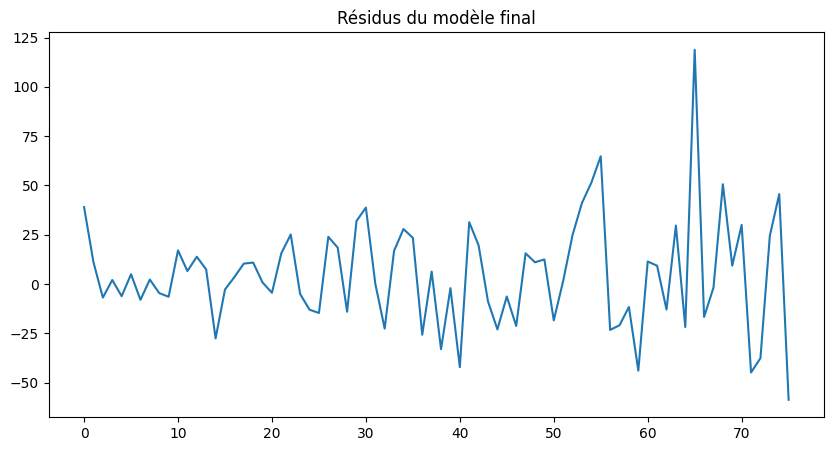

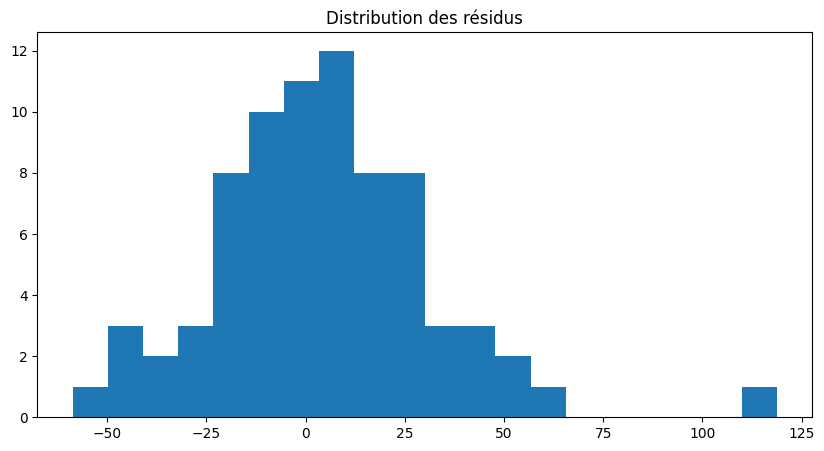

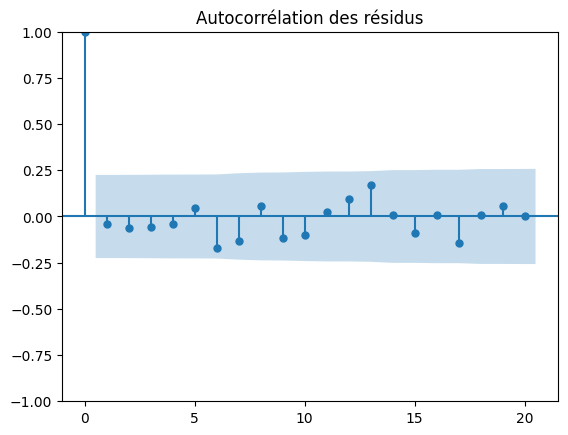

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Récupération des erreurs (résidus)
residuals = model_final_fit.resid

# 1. Tracé temporel
plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Résidus du modèle final")
plt.show()

# 2. Histogramme
plt.figure(figsize=(10,5))
plt.hist(residuals, bins=20)
plt.title("Distribution des résidus")
plt.show()

# 3. ACF des résidus
plot_acf(residuals, lags=20)
plt.title("Autocorrélation des résidus")
plt.show()

In [ ]:
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. On récupère les résidus de ton modèle fitté
residuals = results.resid

# 2. Application du test de Ljung-Box
# On teste généralement sur 10 lags pour vérifier l'absence d'autocorrélation
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)

print(lb_test)

     lb_stat  lb_pvalue
10  4.352645    0.93004


Ainsi après avoir tracer les différents graphe et diagrammes:

1-Bruit blanc car le tracé temporel ne présente pas de structure

2-L'Histogramme presente une cloche gaussienne

3-ENfIN le tracé des résudu de l'acf montre qu'aucune corrélatin ne dépasse la zone en bleue